In [36]:
import os

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder

In [2]:
load_dotenv()
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
output_path = 'data/irrigation-water'
if os.path.exists(output_path):
    print(f"Directory '{output_path}' already exists. Skipping download.")
    path = output_path
else:
    # Download latest version
    path = kagglehub.competition_download('playground-series-s6e4', output_dir=output_path)

    print("Path to competition files:", path)

Directory 'data/irrigation-water' already exists. Skipping download.


In [12]:
test_df = pd.read_csv(os.path.join(path, 'test.zip'), index_col='id')
train_df = pd.read_csv(os.path.join(path, 'train.zip'), index_col='id')

In [13]:
target_encoder = LabelEncoder() # we need decode after prediction
train_df['Irrigation_Need'] = target_encoder.fit_transform(train_df['Irrigation_Need'])

In [14]:
string_columns = train_df.select_dtypes(include=[str]).columns
num_train_df = train_df.drop(columns=string_columns)

In [15]:
num_train_df.head(5)

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Irrigation_Need
id,,,,,,,,,,,,
0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0.82,112.16,1
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,47.16,1
2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,8.24,110.38,1
3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,8.32,53.85,2
4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,7.37,93.19,1


In [18]:
X = num_train_df.drop(columns=['Irrigation_Need'])
y = num_train_df['Irrigation_Need']

In [42]:
X_sample = X.sample(10000)
y_sample = y[X_sample.index]

In [43]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_2_comp = pd.DataFrame(lda.fit_transform(X_sample, y_sample), columns=['Col1', 'Col2'])

Text(0.5, 0.98, 'Raw Data with LinearDiscriminantAnalysis')

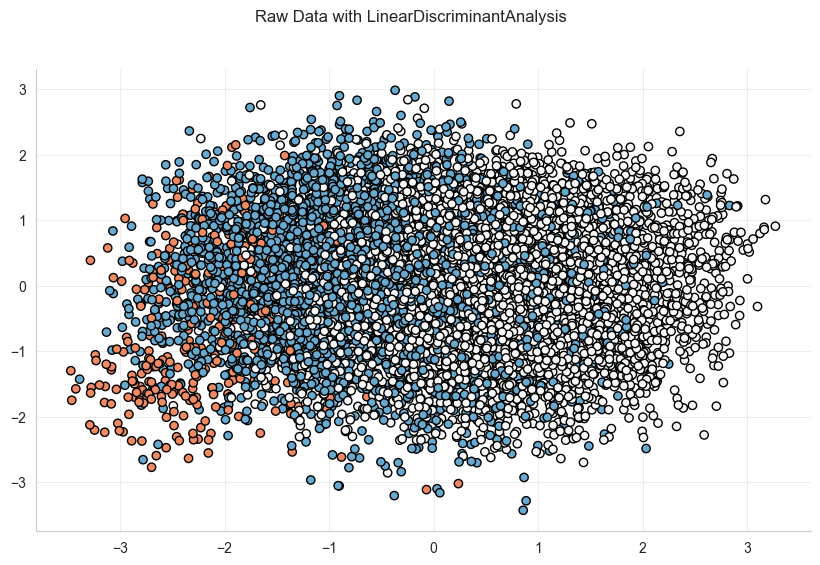

In [44]:
colors = ['#ef8a62' if v == 0 else '#f7f7f7' if v == 1 else '#67a9cf' for v in y_sample]
kwarg_params = {'linewidth': 1, 'edgecolor': 'black'}
plt.scatter(data=X_2_comp,
            x='Col1', y='Col2',
            c=colors,
              **kwarg_params)
sns.despine()
plt.suptitle("Raw Data with LinearDiscriminantAnalysis")